# Stage 1: Spherical Gradient Descent Training (Unshared Embedding)

This notebook demonstrates Stage 1 training with **unshared embedding** (`share_embed=False`), where input embeddings are concatenated: $[e_x; e_y]$.

This is appropriate for **non-commutative** operations like subtraction: $(x - y) \mod n$.

**Phase phenomenon**: For quadratic activation, $\phi_{in}^{(1)} + \phi_{in}^{(2)} \approx \psi_{out}$.

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import matplotlib.pyplot as plt

from src import Config, SphericalTrainer, get_task, get_basis
from src.utils import normalize_to_2pi
from src.plotting import setup_plot_style, make_blue_white_red_cmap, plot_dft_bars, plot_dft_heatmap

setup_plot_style()
blue_white_red = make_blue_white_red_cmap()


## 1. Configuration (Unshared Embedding)

In [2]:
config = Config(
    # Task
    task_name='modular_addition',
    #p=17,           # 1-d case: Z_17
    n=[3,5],       # Z_3 x Z_5
    
    # Model - UNSHARED EMBEDDING
    width=1024,
    act_type='Quad',
    init_scale=0.5,
    share_embed=False,  # Concatenate embeddings [e_x; e_y] instead of sum
    
    # Stage 1: Projected GD on sphere
    stage1_enabled=True,
    stage1_lr=1e-3,
    stage1_num_epochs=1000,
    stage1_optimizer='Adam',
    stage1_freeze_scales=True,
    
    # Stage 2: Disabled
    stage2_enabled=False,
    
    # Logging
    print_every=500,
    track_phases=False,  # Custom phase tracking for unshared
    track_scales=True,
    
    # System
    seed=42,
)

print(f"Device: {config.device}")
print(f"Task: {config.task_name}")
print(f"Moduli: {config.moduli} (vocab_size={config.d_vocab})")
print(f"Model: width={config.width}, activation={config.act_type}")
print(f"share_embed={config.share_embed} -> W_in shape will be (width, 2*vocab_size)")

Device: auto
Task: modular_addition
Moduli: [3, 5] (vocab_size=15)
Model: width=1024, activation=Quad
share_embed=False -> W_in shape will be (width, 2*vocab_size)


## 2. Initialize Trainer

In [3]:
trainer = SphericalTrainer(config)

print(f"\nModel architecture:")
print(f"  W_in:  {trainer.model.W_in.shape}  <- (width, 2*vocab_size) for unshared")
print(f"  W_out: {trainer.model.W_out.shape}")
print(f"  scale_in:  {trainer.model.scale_in.item():.4f}")
print(f"  scale_out: {trainer.model.scale_out.item():.4f}")

print(f"\nBasis: {trainer.basis}")
print(f"Dataset: {len(trainer.data)} samples")

Initialized SphericalTrainer:
  Task: ModularAddition(n=[3, 5], vocab_size=15)
  Basis: FourierBasis(n=[3, 5], size=15)
  Device: cpu
  Data size: 225
  Model:
WideNetworkScaleSphere(
  d_vocab=15,
  width=1024,
  act_type='Quad',
  share_embed=False,
  d_input=30,
  scale_in=0.5000,
  scale_out=0.5000
)

Model architecture:
  W_in:  torch.Size([1024, 30])  <- (width, 2*vocab_size) for unshared
  W_out: torch.Size([15, 1024])
  scale_in:  0.5000
  scale_out: 0.5000

Basis: FourierBasis(n=[3, 5], size=15)
Dataset: 225 samples


## 3. Run Stage 1 Training

In [4]:
# Save initial weights before training
W_in_init = trainer.model.W_in.detach().cpu().clone()
W_out_init = trainer.model.W_out.detach().cpu().clone()

# Run training
stage1_history, stage2_history = trainer.train()


Stage 1: Projected GD (Directions only, Scale fixed)
Fixed scale_in = 0.5000, scale_out = 0.5000


Epoch     0 | Loss: 609.311462 | Acc: 0.0711


Epoch   500 | Loss: 608.970337 | Acc: 1.0000



Stage 1 Final | Loss: 608.968994 | Acc: 1.0000
Stage 2 disabled, skipping...


## 4. Single Frequency Phenomenon

Each neuron tends to specialize to a single dominant frequency in Fourier space.

For `share_embed=False`, W_in has shape `(width, 2*vocab_size)` where:
- First half `W_in[:, :vocab_size]` corresponds to position 1 (x)
- Second half `W_in[:, vocab_size:]` corresponds to position 2 (y)

In [5]:
# Compute Fourier transform of weights (init and trained)
# Using paper's L²(G) DFT convention: ν̂[k] = (1/|G|) Σ_x ν(x) χ_k(x^{-1})
basis = trainer.basis
vocab_size = config.d_vocab

# Get trained weights
W_in = trainer.model.W_in.detach().cpu()
W_out = trainer.model.W_out.detach().cpu()

# Split W_in into position 1 and position 2 (trained)
W_in_pos1 = W_in[:, :vocab_size]   # Shape: (width, vocab_size)
W_in_pos2 = W_in[:, vocab_size:]   # Shape: (width, vocab_size)

# Split W_in_init into position 1 and position 2 (initial)
W_in_init_pos1 = W_in_init[:, :vocab_size]
W_in_init_pos2 = W_in_init[:, vocab_size:]

print(f"W_in shape: {W_in.shape}")
print(f"W_in_pos1 (position x): {W_in_pos1.shape}")
print(f"W_in_pos2 (position y): {W_in_pos2.shape}")
print(f"W_out: {W_out.shape}")

# Normalize each part (trained)
W_in_pos1_norm = W_in_pos1 / W_in_pos1.norm(dim=1, keepdim=True)
W_in_pos2_norm = W_in_pos2 / W_in_pos2.norm(dim=1, keepdim=True)
W_out_norm = W_out / W_out.norm(dim=0, keepdim=True)

# Normalize each part (initial)
W_in_init_pos1_norm = W_in_init_pos1 / W_in_init_pos1.norm(dim=1, keepdim=True)
W_in_init_pos2_norm = W_in_init_pos2 / W_in_init_pos2.norm(dim=1, keepdim=True)
W_out_init_norm = W_out_init / W_out_init.norm(dim=0, keepdim=True)

# Apply Fourier transform with paper's L²(G) scaling (trained)
# For abelian groups, all d_ρ = 1, so ν̂[k] = C[k] / √|G|
W_in_pos1_dft = basis.transform_paper(W_in_pos1_norm)
W_in_pos2_dft = basis.transform_paper(W_in_pos2_norm)
W_out_dft = basis.transform_paper(W_out_norm.T)

# Apply Fourier transform (initial)
W_in_init_pos1_dft = basis.transform_paper(W_in_init_pos1_norm)
W_in_init_pos2_dft = basis.transform_paper(W_in_init_pos2_norm)
W_out_init_dft = basis.transform_paper(W_out_init_norm.T)

# Get magnitudes (trained)
W_in_pos1_mag = torch.abs(W_in_pos1_dft).numpy()
W_in_pos2_mag = torch.abs(W_in_pos2_dft).numpy()
W_out_mag = torch.abs(W_out_dft).numpy()

# Get magnitudes (initial)
W_in_init_pos1_mag = torch.abs(W_in_init_pos1_dft).numpy()
W_in_init_pos2_mag = torch.abs(W_in_init_pos2_dft).numpy()
W_out_init_mag = torch.abs(W_out_init_dft).numpy()

print(f"\nDFT shapes (paper notation ν̂[k] via basis.transform_paper()):")
print(f"W_in_pos1_dft: {W_in_pos1_dft.shape}")
print(f"W_in_pos2_dft: {W_in_pos2_dft.shape}")
print(f"W_out_dft: {W_out_dft.shape}")

# Verify Plancherel: Σ_k |ν̂[k]|² = 1/|G| for unit-norm signals
# For abelian groups, all d_ρ = 1, so Σ_k |ν̂[k]|² = 1/|G|
G_ORDER = vocab_size
total_energy = np.sum(W_in_pos1_mag[0]**2)
print(f"\nVerification (Plancherel): Σ_k |ν̂[k]|² should = 1/|G| = {1/G_ORDER:.6f}")
print(f"  Neuron 0: Σ_k |ν̂[k]|² = {total_energy:.6f}")

W_in shape: torch.Size([1024, 30])
W_in_pos1 (position x): torch.Size([1024, 15])
W_in_pos2 (position y): torch.Size([1024, 15])
W_out: torch.Size([15, 1024])

DFT shapes (paper notation ν̂[k] via basis.transform_paper()):
W_in_pos1_dft: torch.Size([1024, 15])
W_in_pos2_dft: torch.Size([1024, 15])
W_out_dft: torch.Size([1024, 15])

Verification (Plancherel): Σ_k |ν̂[k]|² should = 1/|G| = 0.066667
  Neuron 0: Σ_k |ν̂[k]|² = 0.066667


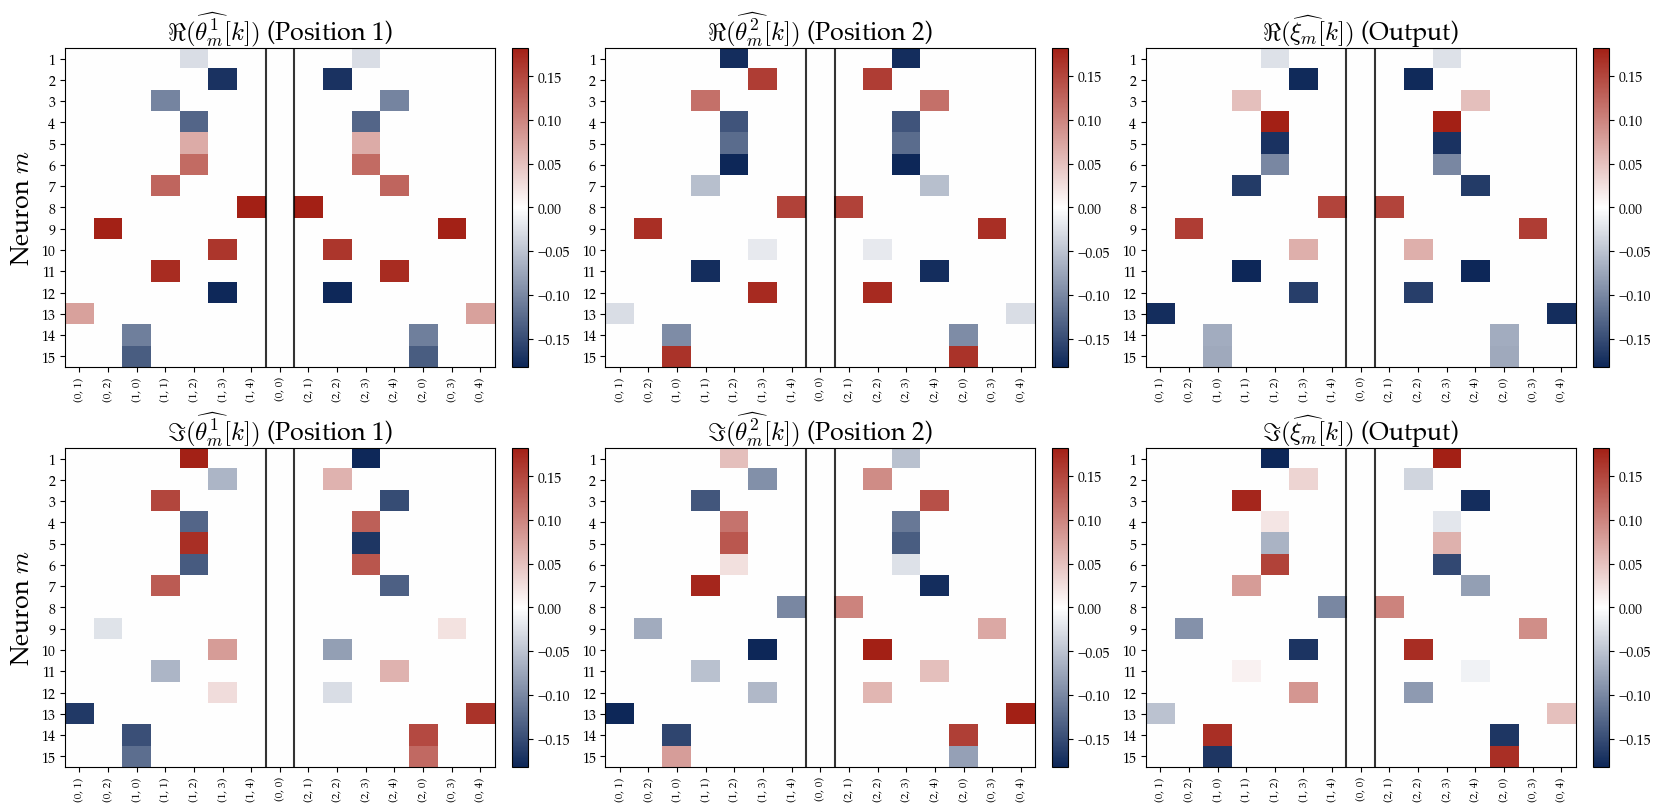

In [6]:
# Build conjugate-symmetric ordering of frequencies
moduli = basis.n
all_tuples = [basis.get_frequency_tuple(k) for k in range(vocab_size)]

def get_conjugate(k_tuple, moduli):
    return tuple((-k) % n for k, n in zip(k_tuple, moduli))

def is_self_conjugate(k_tuple, moduli):
    return k_tuple == get_conjugate(k_tuple, moduli)

self_conj, left_half, right_half, seen = [], [], [], set()
for k_tuple in all_tuples:
    if k_tuple in seen:
        continue
    conj = get_conjugate(k_tuple, moduli)
    if is_self_conjugate(k_tuple, moduli):
        self_conj.append(k_tuple); seen.add(k_tuple)
    else:
        left_half.append(k_tuple); right_half.append(conj)
        seen.add(k_tuple); seen.add(conj)

symmetric_order = left_half + self_conj + right_half[::-1]
reorder_indices = [basis.tuple_to_index(t) for t in symmetric_order]
freq_labels_short = [str(t) for t in symmetric_order]

num_components = 15
W1 = W_in_pos1_dft[:num_components, reorder_indices]
W2 = W_in_pos2_dft[:num_components, reorder_indices]
Wo = W_out_dft[:num_components, reorder_indices]

left_end = len(left_half)
self_conj_end = left_end + len(self_conj)
vlines = [x for x in [left_end - 0.5, self_conj_end - 0.5]
          if 0 < x < vocab_size - 1]

fig = plot_dft_heatmap(
    [W1, W2, Wo],
    [r'$\Re(\widehat{\theta_m^1}[k])$ (Position 1)',
     r'$\Re(\widehat{\theta_m^2}[k])$ (Position 2)',
     r'$\Re(\widehat{\xi_m}[k])$ (Output)'],
    [r'$\Im(\widehat{\theta_m^1}[k])$ (Position 1)',
     r'$\Im(\widehat{\theta_m^2}[k])$ (Position 2)',
     r'$\Im(\widehat{\xi_m}[k])$ (Output)'],
    freq_labels_short,
    vline_positions=vlines,
    cmap=blue_white_red,
)
plt.savefig('../figures/modular_addition_dft_heatmap_example.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()


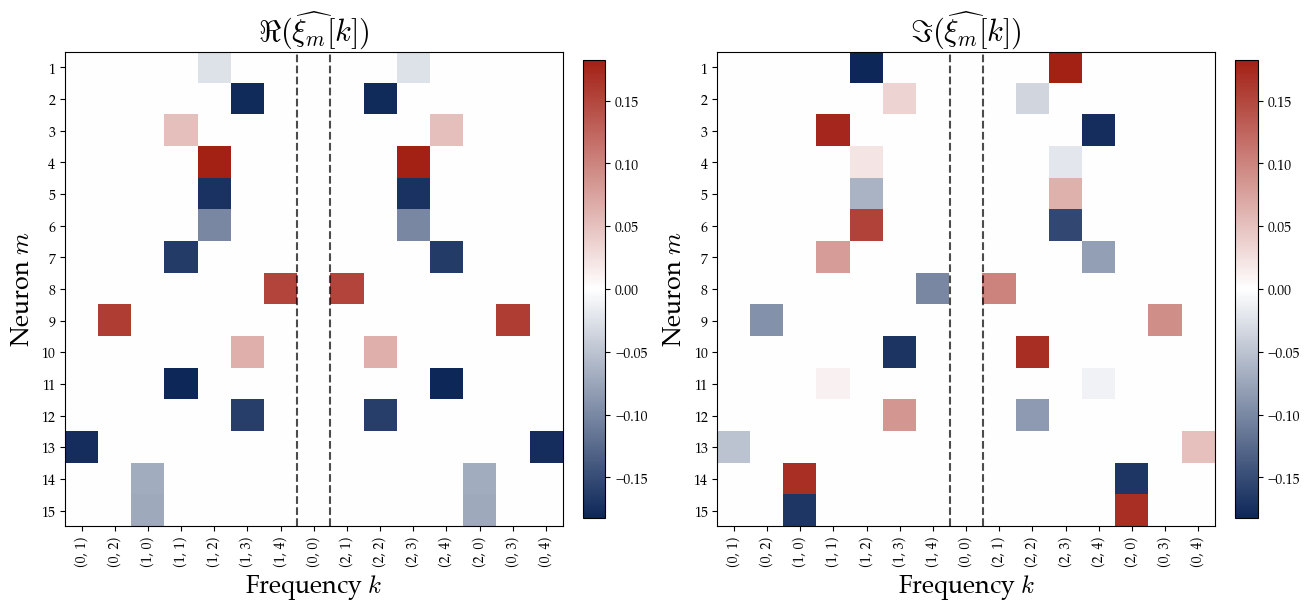

In [7]:
# Heatmap: DFT coefficients of ξ (output weights), Re and Im side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True)

data_out_re = W_out_dft[:num_components, reorder_indices].real.numpy()
data_out_im = W_out_dft[:num_components, reorder_indices].imag.numpy()
vmax_out = max(np.abs(data_out_re).max(), np.abs(data_out_im).max(), 0.1)

for ax, data, title in zip(
    axes,
    [data_out_re, data_out_im],
    [r'$\Re(\widehat{\xi_m}[k])$', r'$\Im(\widehat{\xi_m}[k])$'],
):
    im = ax.imshow(data, cmap=blue_white_red, vmin=-vmax_out, vmax=vmax_out, aspect='auto')
    ax.set_title(title, fontsize=22)
    ax.set_xlabel('Frequency $k$', fontsize=18)
    ax.set_ylabel('Neuron $m$', fontsize=18)
    ax.set_xticks(np.arange(vocab_size))
    ax.set_xticklabels([freq_labels_short[i] for i in range(vocab_size)], rotation=90, fontsize=10)
    ax.set_yticks(np.arange(num_components))
    ax.set_yticklabels(np.arange(num_components) + 1)
    if left_end > 0:
        ax.axvline(x=left_end - 0.5, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
    if self_conj_end < vocab_size:
        ax.axvline(x=self_conj_end - 0.5, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.savefig('../figures/modular_addition_xi_heatmap_example.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()


## 5. Phase Phenomenon

For quadratic activation $\sigma(x) = x^2$ with unshared embedding, we expect the phase relationship:
$$\phi_{in}^{(1)} + \phi_{in}^{(2)} \approx \psi_{out} \pmod{2\pi}$$

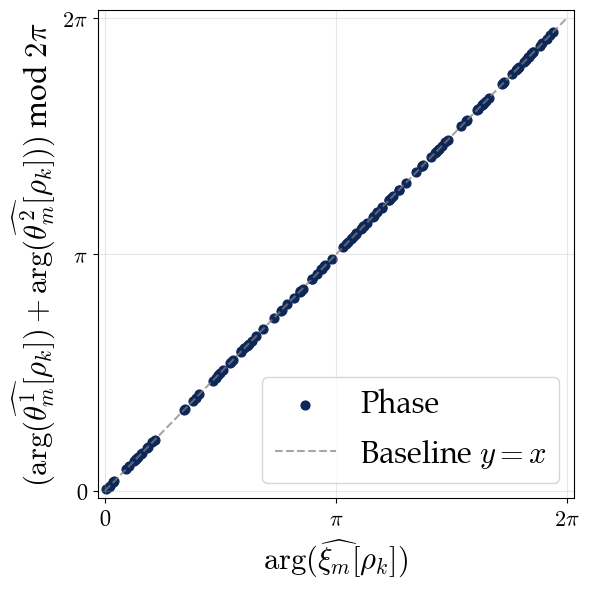

In [8]:
M = 128

phi1_ls, phi2_ls, psi_ls = [], [], []
for m in range(M):
    dom_freq = basis.get_dominant_frequency(W_in_pos1_dft[m])
    if dom_freq == 0:
        continue
    phi1_ls.append(basis.get_phase(W_in_pos1_dft[m], dom_freq))
    phi2_ls.append(basis.get_phase(W_in_pos2_dft[m], dom_freq))
    psi_ls.append(basis.get_phase(W_out_dft[m], dom_freq))

phi1_arr = np.array(phi1_ls)
phi2_arr = np.array(phi2_ls)
psi_arr  = np.array(psi_ls)

phi_sum_arr  = np.array([normalize_to_2pi(p1 + p2) for p1, p2 in zip(phi1_arr, phi2_arr)])
psi_norm_arr = np.array([normalize_to_2pi(p) for p in psi_arr])

cond = (
    ((phi_sum_arr < 0.3) & (psi_norm_arr > 2*np.pi - 0.3)) |
    ((phi_sum_arr > 2*np.pi - 0.3) & (psi_norm_arr < 0.3))
)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(psi_norm_arr[~cond], phi_sum_arr[~cond],
           marker='o', color='#0D2758', s=40, alpha=1, label='Phase')
x_line = np.linspace(0, 2*np.pi, 200)
ax.plot(x_line, x_line, linestyle='--', color='gray', alpha=0.7, linewidth=1.5, label=r'Baseline $y = x$')
ax.set_xlabel(r'$\arg(\widehat{\xi_m}[\rho_{{k}}])$', fontsize=22)
ax.set_ylabel(r'$(\arg(\widehat{\theta^1_m}[\rho_{{k}}])+\arg(\widehat{\theta^2_m}[\rho_{{k}}]))$ mod $2\pi$', fontsize=22)
ax.set_xlim(-0.1, 2*np.pi + 0.1)
ax.set_ylim(-0.1, 2*np.pi + 0.1)
ax.set_xticks([0, np.pi, 2*np.pi])
ax.set_xticklabels(['0', r'$\pi$', r'$2\pi$'], fontsize=16)
ax.set_yticks([0, np.pi, 2*np.pi])
ax.set_yticklabels(['0', r'$\pi$', r'$2\pi$'], fontsize=16)
ax.legend(fontsize=22, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/modular_addition_phase_alignment.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()


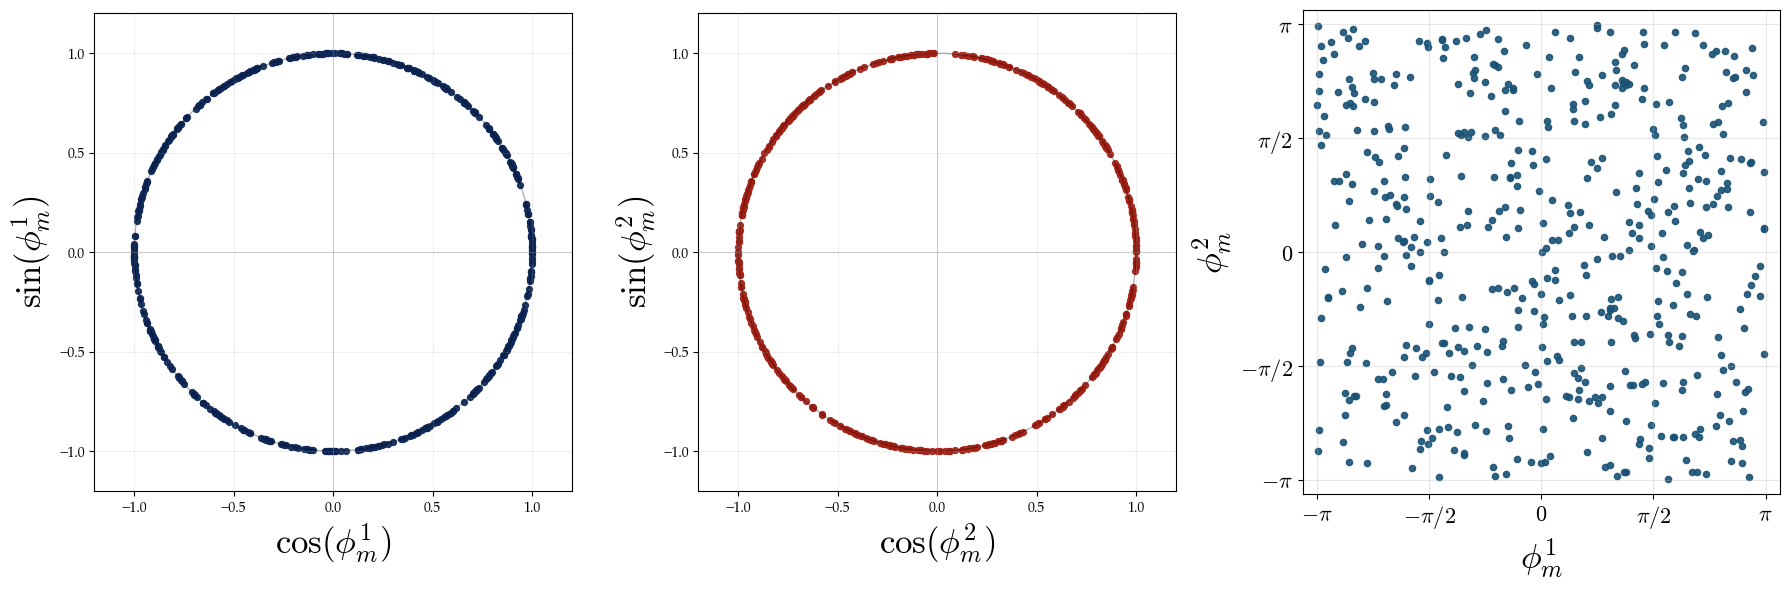

In [9]:
M_phase = 512

phi1_p, phi2_p = [], []
for m in range(M_phase):
    dom_freq = basis.get_dominant_frequency(W_in_pos1_dft[m])
    if dom_freq == 0:
        phi1_p.append(np.nan); phi2_p.append(np.nan); continue
    phi1_p.append(float(torch.angle(W_in_pos1_dft[m, dom_freq])))
    phi2_p.append(float(torch.angle(W_in_pos2_dft[m, dom_freq])))

phi1_p = np.array(phi1_p); phi2_p = np.array(phi2_p)
mask_p = ~(np.isnan(phi1_p) | np.isnan(phi2_p))
phi1_p = phi1_p[mask_p]; phi2_p = phi2_p[mask_p]
theta_circ = np.linspace(0, 2*np.pi, 300)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: phi1 on unit circle
ax = axes[0]
ax.set_aspect('equal')
ax.plot(np.cos(theta_circ), np.sin(theta_circ), 'k-', linewidth=1, alpha=0.3)
ax.scatter(np.cos(phi1_p), np.sin(phi1_p), s=18, alpha=0.9, color='#0D2758')
ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)
ax.set_xlabel(r'$\cos(\phi^1_m)$', fontsize=25)
ax.set_ylabel(r'$\sin(\phi^1_m)$', fontsize=25)
ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2)
ax.grid(True, alpha=0.2)

# Plot 2: phi2 on unit circle
ax = axes[1]
ax.set_aspect('equal')
ax.plot(np.cos(theta_circ), np.sin(theta_circ), 'k-', linewidth=1, alpha=0.3)
ax.scatter(np.cos(phi2_p), np.sin(phi2_p), s=18, alpha=0.9, color='#A32015')
ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)
ax.set_xlabel(r'$\cos(\phi^2_m)$', fontsize=25)
ax.set_ylabel(r'$\sin(\phi^2_m)$', fontsize=25)
ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2)
ax.grid(True, alpha=0.2)

# Plot 3: phi1 vs phi2 scatter
ax = axes[2]
ax.scatter(phi1_p, phi2_p, s=20, alpha=0.9, color='#1A5276')
ax.set_xlabel(r'$\phi^1_m$', fontsize=25)
ax.set_ylabel(r'$\phi^2_m$', fontsize=25)
ax.set_xlim(-np.pi - 0.2, np.pi + 0.2)
ax.set_ylim(-np.pi - 0.2, np.pi + 0.2)
ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_xticklabels([r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'], fontsize=16)
ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_yticklabels([r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'], fontsize=16)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/modular_addition_phase_circles.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()


/var/folders/5n/bjfmhydx1099fm08r1bdw9br0000gn/T/ipykernel_67462/3574194768.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_hist = cm.get_cmap('plasma')


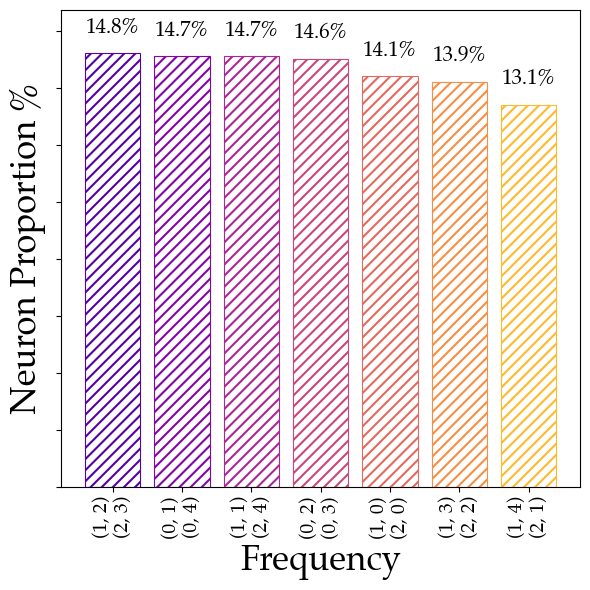

Trivial freq neurons: 0 (0.0%)
  (1, 2) & (2, 3): 152 (14.8%)
  (0, 1) & (0, 4): 151 (14.7%)
  (1, 1) & (2, 4): 151 (14.7%)
  (0, 2) & (0, 3): 150 (14.6%)
  (1, 0) & (2, 0): 144 (14.1%)
  (1, 3) & (2, 2): 142 (13.9%)
  (1, 4) & (2, 1): 134 (13.1%)


In [10]:
# Histogram: neuron count per conjugate pair, x-axis shows both k and -k

def get_conjugate(k_tuple, moduli):
    return tuple((-k) % n for k, n in zip(k_tuple, moduli))

def is_self_conjugate(k_tuple, moduli):
    return k_tuple == get_conjugate(k_tuple, moduli)

moduli = basis.n
M_hist = M_phase*2

freq_counts = {k: 0 for k in range(vocab_size)}
for m in range(M_hist):
    dom = basis.get_dominant_frequency(W_in_pos1_dft[m])
    freq_counts[dom] += 1

seen = set()
groups = []  # (label, count)
for k in range(vocab_size):
    if k in seen:
        continue
    k_tuple = basis.get_frequency_tuple(k)
    conj_tuple = get_conjugate(k_tuple, moduli)
    conj_idx = basis.tuple_to_index(conj_tuple)
    if k == 0:
        groups.append(('trivial', freq_counts[k]))
        seen.add(k)
    elif is_self_conjugate(k_tuple, moduli):
        groups.append((str(k_tuple), freq_counts[k]))
        seen.add(k)
    else:
        combined = freq_counts[k] + freq_counts[conj_idx]
        # Label shows both irrep and its conjugate
        label = f'{k_tuple}\n{conj_tuple}'
        groups.append((label, combined))
        seen.add(k)
        seen.add(conj_idx)

groups_nontrivial = [(l, c) for l, c in groups if l != 'trivial']
groups_nontrivial.sort(key=lambda x: -x[1])
labels_hist = [g[0] for g in groups_nontrivial]
counts_hist = [g[1] for g in groups_nontrivial]

import matplotlib.cm as cm
cmap_hist = cm.get_cmap('plasma')
bar_colors = [cmap_hist(0.15 + 0.70 * i / max(len(counts_hist) - 1, 1)) for i in range(len(counts_hist))]

import matplotlib as mpl
mpl.rcParams['hatch.linewidth'] = 1.5

fig, ax = plt.subplots(figsize=(6, 6))
bars = ax.bar(np.arange(len(labels_hist)), counts_hist, facecolor='none', linewidth=0.8, hatch='///')
# Set each bar's edge/hatch color individually
for bar, color in zip(bars, bar_colors):
    bar.set_edgecolor(color)

ax.set_xticks(np.arange(len(labels_hist)))
ax.set_xticklabels(labels_hist, rotation=90, ha='center', fontsize=14)
ax.set_xlabel('Frequency', fontsize=25)
ax.set_ylabel('Neuron Proportion %', fontsize=25)
for bar, cnt in zip(bars, counts_hist):
    if cnt > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + M_hist * 0.005,
                f'{cnt/M_hist:.1%}', ha='center', va='bottom', fontsize=15)
ax.set_ylim(0, max(counts_hist) * 1.10)
ax.set_yticklabels([])
plt.tight_layout()
plt.savefig('../figures/modular_addition_freq_distribution_histogram.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()

trivial_count = dict(groups).get('trivial', 0)
print(f'Trivial freq neurons: {trivial_count} ({trivial_count/M_hist:.1%})')
for l, c in groups_nontrivial:
    print(f'  {l.replace(chr(10), " & ")}: {c} ({c/M_hist:.1%})')
